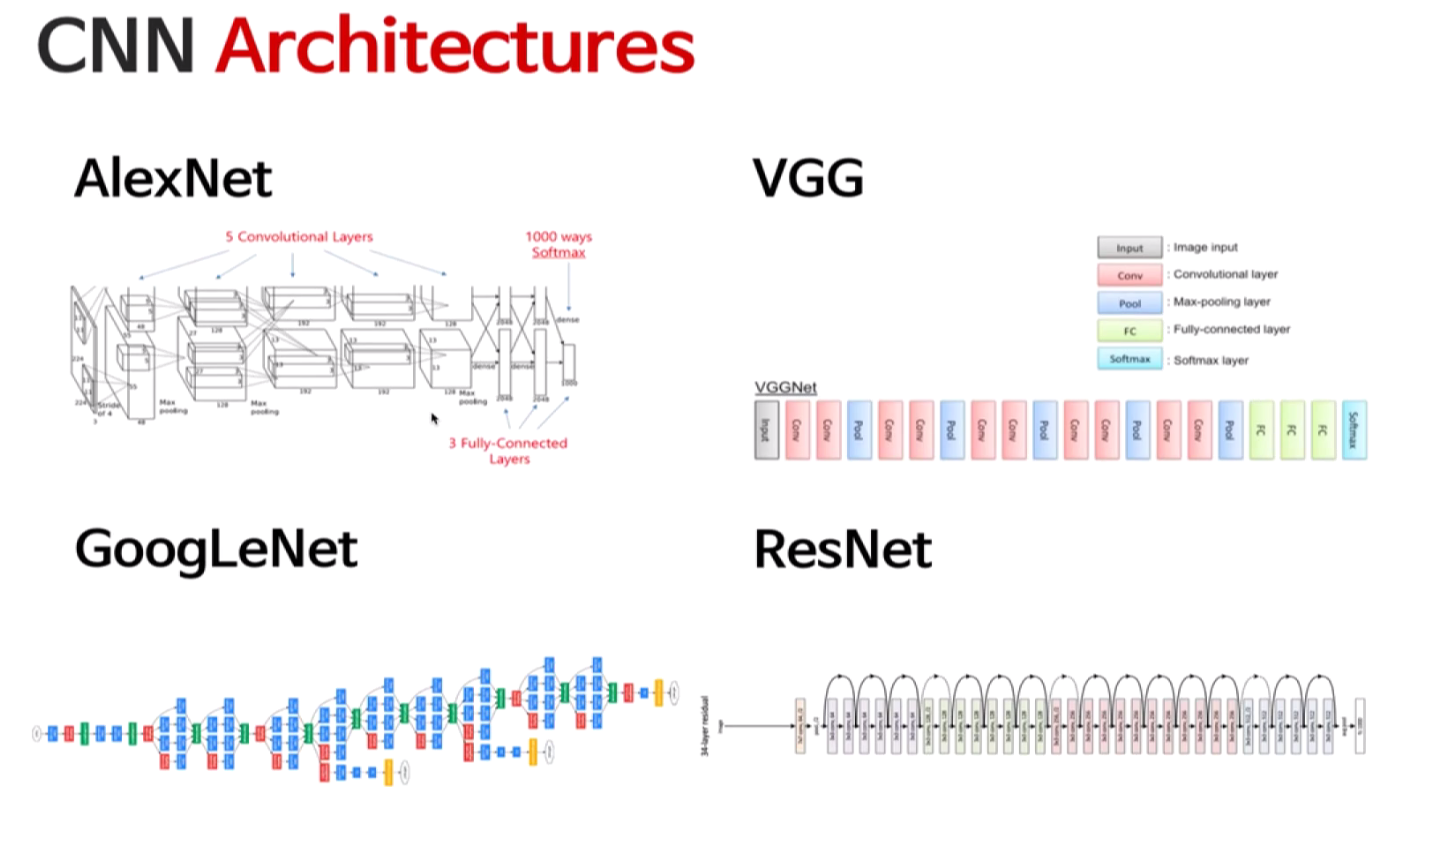

* Transfer Learning methods developed by universities (AlexNet from University of Toronto; ) and big companies like Google (GoogLeNet), Facebook (ResNet), Microsoft (Turing-NLG for NLP). 


* The process of **adjusting our data** according **to** our chosen **transfer learning model** is called **Fine Tuning**.

In [1]:
# Keras web page:  https://keras.io/api/applications/

In [2]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
os.getcwd()

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\06 Transfer Learning Cats & Dogs'

The Dogs vs. Cats dataset is a common computer vision dataset in which pictures are classified as either including a dog or a cat.

After the dataset is well studied, it can be used to understand and practice how to design, evaluate, and apply convolutional neural networks for image classification.

You will build a classifier with images and try to detect dogs versus cats using CNN.

Train set includes 12500 cat-5026 dog images, validation set includes 1219 cat-1071 dog images and test set incgludes 6897 cat and dogs images together. 

In [4]:
my_data_dir='datam/'

In [5]:
os.listdir(my_data_dir)

['test', 'train']

In [6]:
train_path = my_data_dir+'train'
test_path = my_data_dir+'test'

In [7]:
os.listdir(train_path)

['cat', 'dog']

**Let's check how many images there are.**

In [8]:
len(os.listdir(train_path+'/cat'))

12500

In [9]:
len(os.listdir(train_path+'/dog'))

5026

In [10]:
os.listdir(train_path+'/cat')[0]

'cat.0.jpg'

In [11]:
path1=train_path+'/cat'+'/cat.1000.jpg'
path2=train_path+'/dog'+'/dog.1000.jpg'

In [12]:
cat_img=imread(path1)
dog_img=imread(path2)

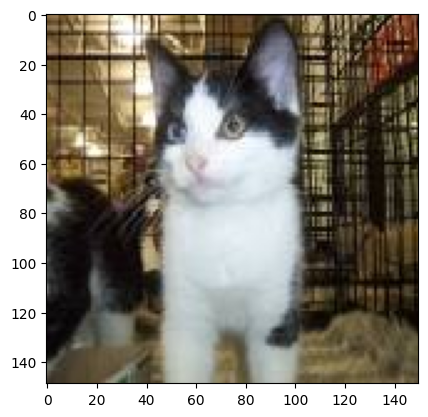

In [13]:
plt.imshow(cat_img);

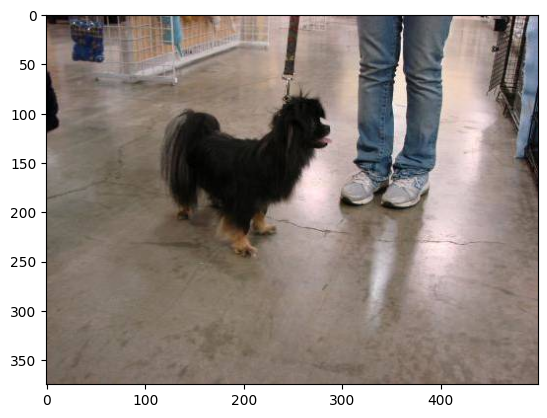

In [14]:
plt.imshow(dog_img);

**Let's decide on the final dimension of these images.**

In [15]:
cat_img.max()

np.uint8(255)

In [16]:
cat_img.min()

np.uint8(0)

In [17]:
cat_img.shape

(149, 150, 3)

In [18]:
dog_img.shape

(375, 499, 3)

In [19]:
x= []
y = []
for image in os.listdir(train_path+'/cat'):
    
    img = imread(train_path+'/cat/'+image)
    d1,d2,colors = img.shape
    x.append(d1)
    y.append(d2)

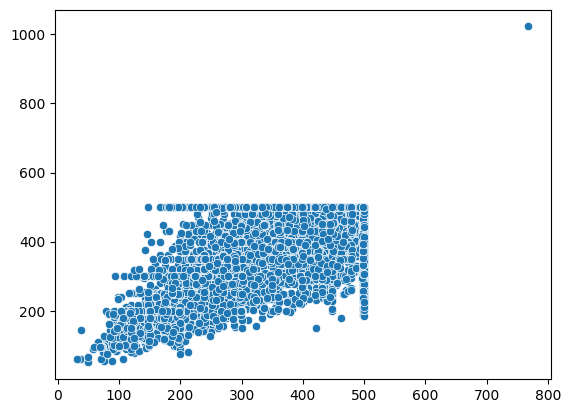

In [20]:
sns.scatterplot(x=x,y=y);

In [21]:

np.mean(x)

np.float64(356.46712)

In [22]:
np.mean(y)

np.float64(410.52264)

In [23]:
image_shape = (224, 224,3) # Since VGG16 trained on (224, 224, 3) images. https://keras.io/api/applications/vgg/#vgg16-function

In [24]:
# help(ImageDataGenerator)

**Image Manipulation**

We can use the ImageDataGenerator to manipulate the images with rotation, resizing, and scaling so the model becomes more robust to different images that our data set doesn't have. ImageDataGenerator does the followings.

* Accepts a batch of images used for training.
* Applies a series of random transformations to each image in the batch.
* Replaces the original batch with randomly transformed batch.
* Training the CNN on this randomly transformed batch.

The goal of applying data augmentation is to have a more generalized model.

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input # For preprocessing (rescaling)

In [26]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               
                               #rescale=1/255, # Rescale the image by normalzing it.DON't DO IT
                               
                               preprocessing_function=preprocess_input,  # Apply VGG16 preprocessing here
                               
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

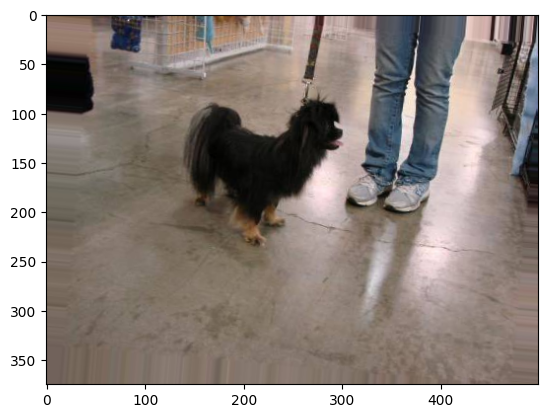

In [27]:
plt.imshow(image_gen.random_transform(dog_img));

image_gen.flow_from_directory(train_path)

# Creating the Model

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

In transfer learning models; 

1) **include_top=False** --> We are setting up the ANN part.

2) **weights= "imagenet"** --> Use the weights learned while training on imageNet data.

3) **layer.trainable=False** --> The model doesn't trained from scratch, the weights it has previously learned should be used.

## VGG16


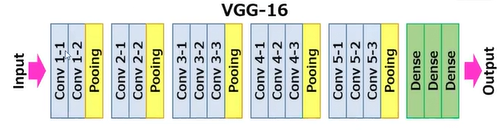



There isn't "**include_preprocessing=True**" in VGG16 model. **We must do it** before the seting up the model.   

https://keras.io/api/applications/vgg/#vgg16-function


https://medium.com/academy-team/deep-learningde-transfer-learning-modellerini-kullan%C4%B1rken-dikkat-edilmesi-gereken-noktalar-15d1e2ad2f96

**While using a Transfer Learning model:***

- **include_top=False** --> meaning I will set ANN

- **weights= "imagenet"** --> meaning use the model weights while it trained on imagenet. 

- **layer.trainable=False** --> meaning don't train again the model, I want  tu use VGG16's weights. 

In [29]:
# from keras.applications.vgg16 import VGG16

In [30]:
vgg16_model = Sequential()


pretrained_model= tf.keras.applications.VGG16(include_top=False, # I will set ANN. If you schoose "True", you will use ptre-trained model's ANN. 
                   input_shape=image_shape,
                   pooling='avg',
                   weights= "imagenet")
for layer in pretrained_model.layers:
        layer.trainable=False       # Don't train again the model, use VGG16's weights. If tou make "True", all wights are deleted and this architecthture is trained for our data. 

vgg16_model.add(pretrained_model)         

             


vgg16_model.add(Flatten())

vgg16_model.add(Dense(64, activation='relu'))
vgg16_model.add(Dense(1, activation='sigmoid')) # binary classification
vgg16_model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [31]:
vgg16_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 512)                 │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Early Stopping

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [34]:
batch_size = 64

In [35]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(224, 224),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True)

Found 17526 images belonging to 2 classes.


In [36]:
image_gen_test = ImageDataGenerator(preprocessing_function=preprocess_input) # Empty image generator; just I added "preprocessing_function=preprocess_input"

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                                   target_size=(224, 224),
                                                   
                                                   color_mode='rgb',
                                                   
                                                   batch_size=batch_size,
                                                   
                                                   class_mode='binary', shuffle=False)

Found 2290 images belonging to 2 classes.


## Model Training

In [37]:
results = vgg16_model.fit(train_image_gen,epochs=5,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1917s 7s/step - accuracy: 0.9223 - loss: 0.2717 - val_accuracy: 0.9633 - val_loss: 0.1975
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1939s 7s/step - accuracy: 0.9811 - loss: 0.0537 - val_accuracy: 0.9672 - val_loss: 0.2345
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1831s 7s/step - accuracy: 0.9859 - loss: 0.0385 - val_accuracy: 0.9629 - val_loss: 0.2515
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1900s 7s/step - accuracy: 0.9855 - loss: 0.0365 - val_accuracy: 0.9672 - val_loss: 0.2450


# Evaluating the Model

In [38]:
summary = pd.DataFrame(vgg16_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.963597,0.114016,0.963319,0.197471
1,0.982141,0.051538,0.967249,0.234547
2,0.985507,0.039449,0.962882,0.251514
3,0.986648,0.036767,0.967249,0.245009


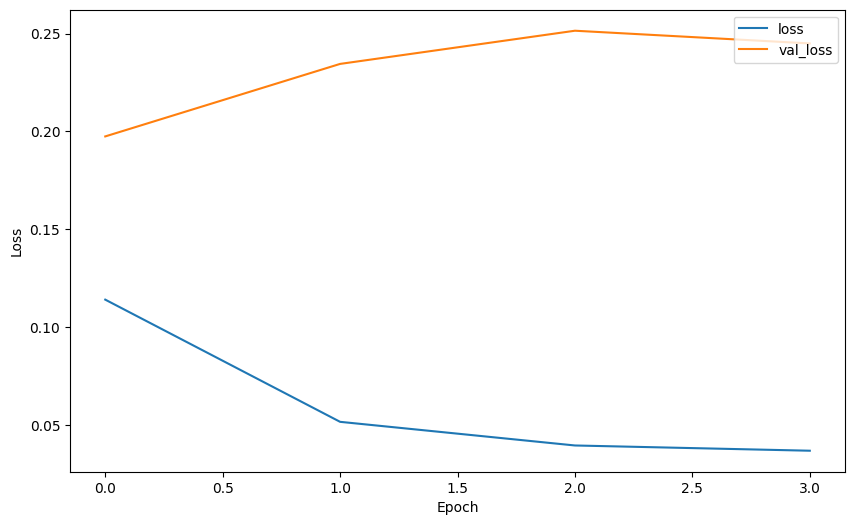

In [39]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

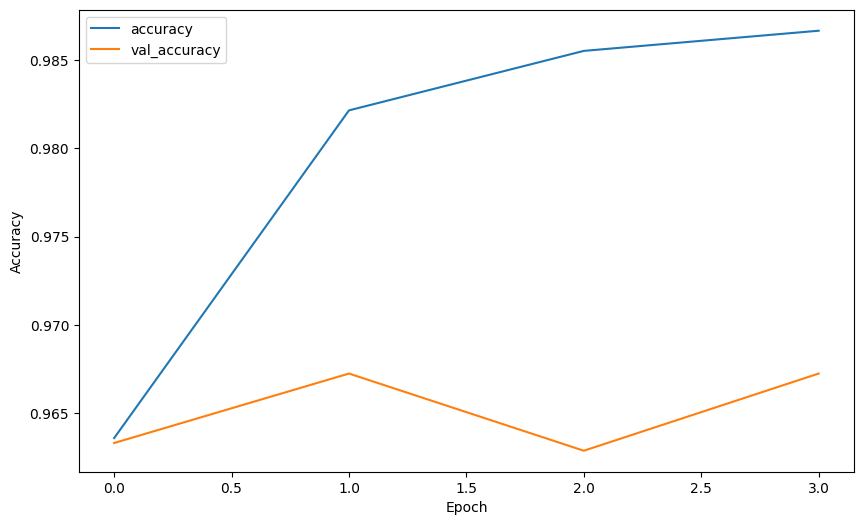

In [40]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [41]:
vgg16_model.metrics_names

['loss', 'compile_metrics']

In [42]:
vgg16_model.evaluate(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 232s 6s/step - accuracy: 0.9842 - loss: 0.1232


[0.24500881135463715, 0.9672489166259766]

In [43]:
pred_probabilities = vgg16_model.predict(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 227s 6s/step


In [44]:
pred_probabilities

array([[2.2527978e-07],
       [2.0255789e-05],
       [5.3506727e-17],
       ...,
       [9.9946028e-01],
       [9.9999946e-01],
       [1.0000000e+00]], dtype=float32)

In [45]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

In [46]:
predictions = pred_probabilities > 0.5

In [47]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [48]:
from sklearn.metrics import classification_report,confusion_matrix

In [49]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1219
           1       0.99      0.94      0.96      1071

    accuracy                           0.97      2290
   macro avg       0.97      0.97      0.97      2290
weighted avg       0.97      0.97      0.97      2290



In [50]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1208,   11],
       [  64, 1007]])

From **Kaggle**: https://www.kaggle.com/code/bhuvanchennoju/hey-siri-is-it-a-or-class-f1-0-992